
If the random variables which make up $y_t$ are uncorrelated, have means 0 and variance $\sigma^2$, then $y_t$ is stationary with an autocovariance function of

$$
\gamma_w(s,t) = \text{cov}(w_s, w_t)=
\begin{cases}
\sigma^2_w  & s=t \\
0 & \text{otherwise}
\end{cases}
$$

This type of series is referred to as [**white noise**](https://en.wikipedia.org/wiki/White_noise). The designation *white* originates from the analogy with white light and indicates that all possible periodic oscillations are present with equal strength ([Shumway and Stoffer 2011](http://www.springer.com/gp/book/9783319524511)).

A particularly useful white noise series is *Gaussian white noise*, wherein the $w_t$ are independent and identically distributed (*iid*) normal random variables, with mean 0 and variance $\sigma^2$.


$$w_t \sim \text{iid } N(0, \sigma^2_w) $$

We may easily generate a Gaussian white noise in Python:


In [1]:
%load_ext lab_black

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import random
from pandas import Series
from pandas.plotting import autocorrelation_plot

In [3]:
# seed random number generator
random.seed(1)

# create white noise series
series = [random.gauss(0.0, 1.0) for i in range(100)]
series = Series(series)

# summary stats
print(series.describe())

count    100.000000
mean      -0.050576
std        0.944013
min       -2.835791
25%       -0.609139
50%        0.010431
75%        0.556549
max        2.389112
dtype: float64


<Figure size 1800x600 with 0 Axes>

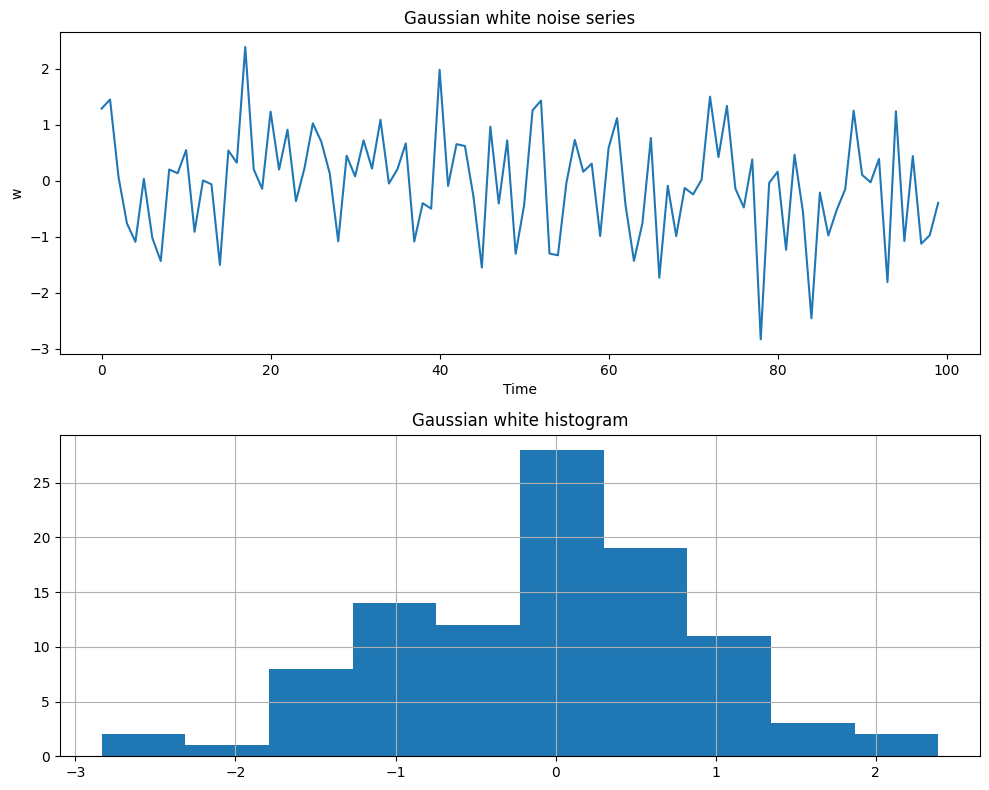

In [4]:
# plot
plt.figure(figsize=(18, 6))
fig, axs = plt.subplots(2, 1, figsize=(10, 8))

series.plot(ax=axs[0])
axs[0].set_title("Gaussian white noise series")
axs[0].set_xlabel("Time")
axs[0].set_ylabel("w")


# histogram plot
series.hist(ax=axs[1])
axs[1].set_title("Gaussian white histogram")

plt.tight_layout()
plt.show()

Let us plot the correlogram by using the [`autocorrelation_plot()`](https://pandas.pydata.org/docs/reference/api/pandas.plotting.autocorrelation_plot.html) function. Finally, we check for any autocorrelation with lag variables. 

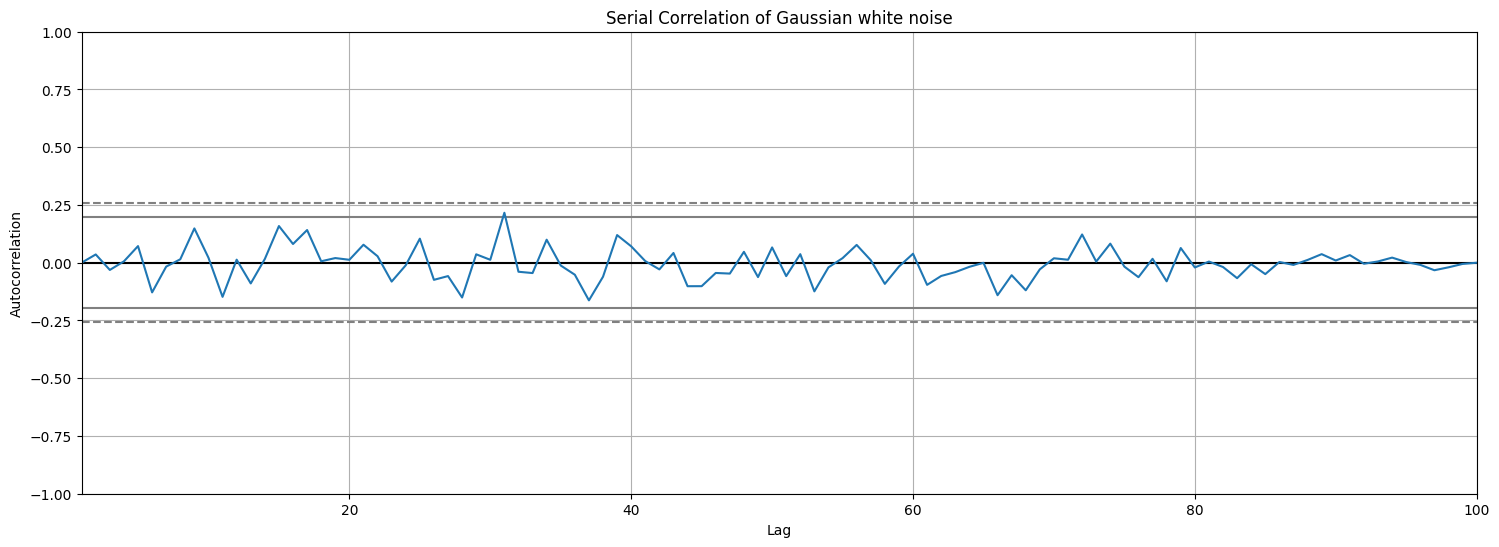

In [5]:
# autocorrelation
plt.figure(figsize=(18, 6))

autocorrelation_plot(series)
plt.title("Serial Correlation of Gaussian white noise")
plt.show()

The correlogram does not show any obvious autocorrelation pattern.

There are some spikes above the 95% and 99% confidence level, but these are a statistical fluke.

Summary: 
* White noise time series is defined by a zero mean, constant variance, and zero correlation.
* If your time series is white noise, it cannot be predicted, and if your forecast residuals are not white noise, you may be able to improve your model.
* The statistics and diagnostic plots you can use on your time series to check if it is white noise.



#### What is autocorrelation and what are partial autocorrelation functions?

Autocorrelation is simply the correlation of a series with its own lags. If a series is significantly autocorrelated, that means, the previous values of the series (lags) may be helpful in predicting the current value.

Partial Autocorrelation also conveys similar information but it conveys the pure correlation of a series and its lag, excluding the correlation contributions from the intermediate lags.

A lag plot is a scatter plot of a time series against a lag of itself. It is normally used to check for autocorrelation. If there is any pattern existing in the series like the one you see below, the series is autocorrelated. If there is no such pattern, the series is likely to be random white noise. The [`pandas.plotting`](https://pandas.pydata.org/pandas-docs/stable/reference/plotting.html) provides the [`lag_plot`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.plotting.lag_plot.html) function for easy plotting.

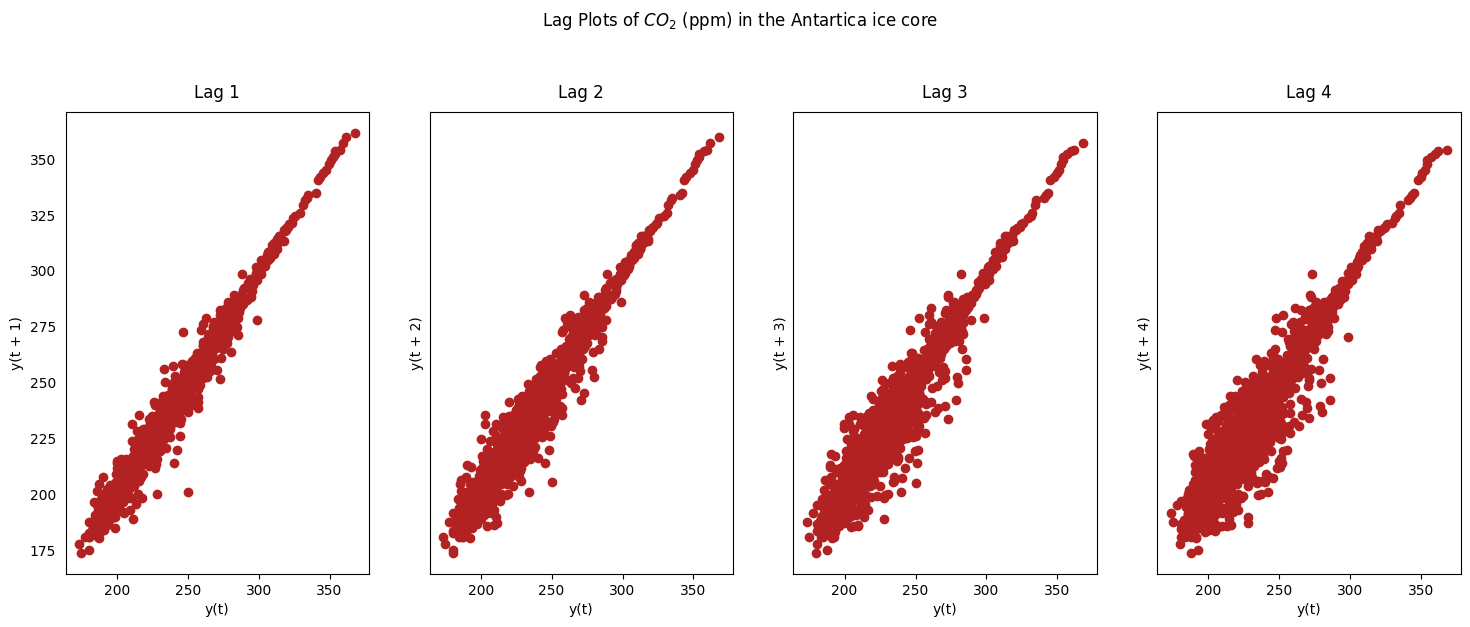

In [6]:
from pandas.plotting import lag_plot

plt.rcParams.update({"ytick.left": False, "axes.titlepad": 10})

# Import example time series, Antartica ice core data
ice_core = pd.read_json(
    "http://userpage.fu-berlin.de/soga/soga-py/300/307000_time_series/Antartica_Ice_Core.json"
)
ice_core = (
    pd.read_json(
        "http://userpage.fu-berlin.de/soga/soga-py/300/307000_time_series/Antartica_Ice_Core.json"
    )
    .set_index("ky_BP_AICC2012")
    .squeeze()
)
ice_core


# Plot

fig, axes = plt.subplots(1, 4, figsize=(18, 6), sharex=True, sharey=True, dpi=100)
for i, ax in enumerate(axes.flatten()[:4]):
    lag_plot(ice_core, lag=i + 1, ax=ax, c="firebrick")
    ax.set_title("Lag " + str(i + 1))

fig.suptitle("Lag Plots of $CO_2$ (ppm) in the Antartica ice core ", y=1.05)
plt.show()

In [1]:
import urllib.request

fp = urllib.request.urlopen("https://userpage.fu-berlin.de/soga/soga-py/citation/citation_py.html")
mybytes = fp.read()

citation = mybytes.decode("utf8")
fp.close()

from IPython.display import display, HTML
display(HTML(citation))